In [68]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
import sys
from tqdm import tqdm
import cv2

### Dataset & Transforms

In [69]:
class DoodleDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [70]:
transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.Grayscale(),
        transforms.ToTensor(),])

In [71]:
dataset = DoodleDataset(data_dir="image_doodle_dataset", transform=transform)

In [72]:
dataset[0][0].shape
dataset[0][0]

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])

In [73]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

### Model

In [74]:
class DoodleClassifier(nn.Module):
    def __init__(self, num_classes=6, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 64x64 to 32x32
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 2: 32x32 to 16x16
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )

        # Global average pool removes spatial dims -> (B, 64, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


In [75]:
model = DoodleClassifier()

### Training Loop

In [76]:
train_folder = r'split_doodle_dataset_v2/train'
valid_folder = r'split_doodle_dataset_v2/val'
test_folder = r'split_doodle_dataset_v2/test'

train_dataset = DoodleDataset(train_folder, transform=transform)
val_dataset = DoodleDataset(valid_folder, transform=transform)
test_dataset = DoodleDataset(test_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [77]:
import torch
from torch import nn, optim
from tqdm import tqdm

num_epochs = 12
train_losses, val_losses = [], []
train_accs, val_accs = [], []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = DoodleClassifier(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    return correct

best_val_acc = 0.0

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += accuracy_from_logits(outputs, labels)
        total_train += batch_size

    train_loss = running_loss / total_train
    train_acc = running_correct / total_train
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - val"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += accuracy_from_logits(outputs, labels)
            total_val += batch_size

    val_loss = running_loss / total_val
    val_acc = running_correct / total_val
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Track best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- Train loss: {train_loss:.4f}, acc: {train_acc:.4f} "
        f"- Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

# restore best weights after training
model.load_state_dict(best_state)


Epoch 1/12 - val: 100%|██████████| 563/563 [00:04<00:00, 136.70it/s]


Epoch 1/12 - Train loss: 0.3933, acc: 0.8708 - Val loss: 0.2438, acc: 0.9232


Epoch 2/12 - val: 100%|██████████| 563/563 [00:04<00:00, 139.17it/s]


Epoch 2/12 - Train loss: 0.2422, acc: 0.9252 - Val loss: 0.2415, acc: 0.9207


Epoch 3/12 - val: 100%|██████████| 563/563 [00:03<00:00, 140.81it/s]


...

Epoch 11/12 - val: 100%|██████████| 563/563 [00:03<00:00, 142.81it/s]


Epoch 11/12 - Train loss: 0.1332, acc: 0.9588 - Val loss: 0.0991, acc: 0.9691


Epoch 12/12 - val: 100%|██████████| 563/563 [00:03<00:00, 141.37it/s]

Epoch 12/12 - Train loss: 0.1277, acc: 0.9607 - Val loss: 0.0980, acc: 0.9702


<All keys matched successfully>

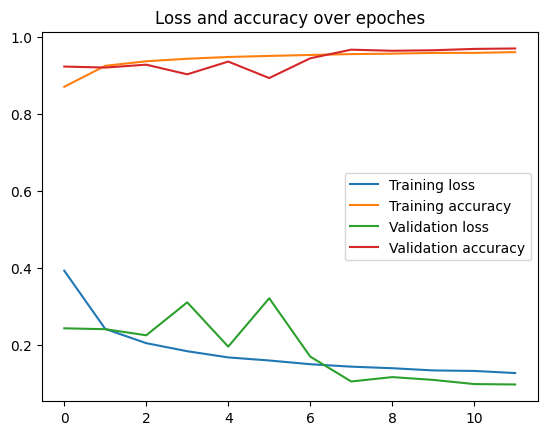

In [ ]:
plt.plot(train_losses, label='Training loss')
plt.plot(train_accs, label='Training accuracy')

plt.plot(val_losses, label='Validation loss')
plt.plot(val_accs, label='Validation accuracy')

plt.legend()
plt.title("Loss and accuracy over epoches")
plt.ylim(top=1)
plt.show()


In [79]:
torch.save(best_state, "doodle_classifier.pth")

In [80]:
model.eval()
criterion = nn.CrossEntropyLoss()

test_running_loss = 0.0
test_running_correct = 0
test_total = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        test_running_loss += loss.item() * batch_size
        test_running_correct += accuracy_from_logits(outputs, labels)
        test_total += batch_size

        all_preds.append(outputs.argmax(dim=1).cpu())
        all_targets.append(labels.cpu())

test_loss = test_running_loss / test_total
test_acc = test_running_correct / test_total

print(f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

# --- Confusion matrix & per-class accuracy (PyTorch only) ---
import torch

targets = torch.cat(all_targets)
preds = torch.cat(all_preds)

num_classes = int(targets.max().item() + 1)
confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64)
for t, p in zip(targets, preds):
    confmat[t, p] += 1

per_class_acc = confmat.diag().float() / confmat.sum(dim=1).clamp(min=1).float()

# Try to show class names if your dataset provides them
idx_to_class = None
if hasattr(test_dataset, "class_to_idx"):
    idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

print("\nPer-class accuracy:")
for i in range(num_classes):
    cls_name = idx_to_class[i] if idx_to_class and i in idx_to_class else f"class_{i}"
    print(f"  {cls_name:<20} {per_class_acc[i].item():.4f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(confmat.numpy())


Test: 100%|██████████| 563/563 [00:04<00:00, 138.60it/s]


Test loss: 0.1065, Test acc: 0.9693

Per-class accuracy:
  class_0              0.9717
  class_1              0.9843
  class_2              0.9697
  class_3              0.9633
  class_4              0.9650
  class_5              0.9617

Confusion matrix (rows=true, cols=pred):
[[2915    7   10    7   16   45]
 [  18 2953    6    3    3   17]
 [  25   13 2909    5   18   30]
 [  41   34    6 2890    4   25]
 [  59    6   16    4 2895   20]
 [  72   14   20    5    4 2885]]


In [81]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("L")
    return image, transform(image)

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        print(probabilities)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(7, 3))
    
    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    
    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

In [82]:
from glob import glob
test_images = glob('split_doodle_dataset_v2/test/*/*')
print(len(test_images))
test_examples = np.random.choice(test_images, 10)
# print(test_examples)
# for image in test_examples:
#     original_image, image_tensor = preprocess_image(image, transform)
#     probabilities = predict(model, image_tensor, device)
    
#     # Assuming dataset.classes gives the class names
#     class_names = dataset.classes 
#     visualize_predictions(original_image, probabilities, class_names)

18000


In [ ]:
# from glob import glob
# test_images = glob('split_doodle_dataset_v2/test/*/*')
# test_examples = np.random.choice(test_images, 10)

# for image in test_examples:
#     original_image, image_tensor = preprocess_image(image, transform)
#     probabilities = predict(model, image_tensor, device)
    
#     # Assuming dataset.classes gives the class names
#     class_names = dataset.classes
#     visualize_predictions(original_image, probabilities, class_names)

ValueError: expected 4D input (got 3D input)